In [1]:
import os
os.environ["KERAS_BACKEND"] = "torch"
os.environ["CUDA_VISIBLE_DEVICES"] = ""

In [2]:
import bayesflow as bf
import torch
import numpy as np
import pandas as pd
import numpy as np
import keras
# from models import prior_1a, simulator_1a, all_models
from bayesflow_models.DDM_DC_Pedestrain_TrialWise import all_models
import os

INFO:bayesflow:Using backend 'torch'
When using torch backend, we need to disable autograd by default to avoid excessive memory usage. Use

with torch.enable_grad():
    ...

in contexts where you need gradients (e.g. custom training loops).


In [3]:
all_models['model_DC_TwoBoundary_Simplest']

 Adapter([0: Broadcast -> 1: AsSet -> 2: Standardize(include=['x']) -> 3: Sqrt -> 4: ConvertDType -> 5: Concatenate(['theta', 'b0', 'mu_ndt', 'mu_alpah'] -> 'inference_variables') -> 6: Rename('x' -> 'summary_variables')])]

In [4]:
base_dir = os.getcwd()
base_dir

'/media/mohammad/atp/Articles/JointModel/Matin/train_joint_models'

In [5]:
base_dir = os.getcwd()
save_dir = os.path.join(base_dir, "trained_model1", "checkpoints")
save_dir
model_names = list(all_models.keys())
model_name1 = model_names[0]
print(model_name1)
save_path = os.path.join(save_dir, model_name1 + ".keras")
save_path
approximator = keras.saving.load_model(save_path)

model_DC_TwoBoundary_Simplest


In [6]:
model,adapt = all_models[model_name1]
model

## Test DDM_DC_Pedestrain

In [9]:
CONDITIONS = np.array([2.0, 3.5, 5.0])
PARAM_KEYS = ['theta', 'b0', 'k', 'mu_ndt', 'sigma_ndt', 'mu_alpah', 'sigma_alpha', 'sigma_cpp']


def subset_condition(batch, tta_value):
    """Slice the flat simulator output to keep only samples with the desired TTA."""
    if "tta_condition" not in batch:
        raise KeyError("Simulator output missing 'tta_condition'. Ensure DDM_DC_Pedestrain models are loaded.")

    mask = batch["tta_condition"] == tta_value
    if not np.any(mask):
        raise ValueError(f"Need more samples for TTA {tta_value}")

    subset = {key: batch[key][mask] for key in PARAM_KEYS}
    subset["x"] = batch["x"][mask]
    subset["number_of_trials"] = batch["number_of_trials"][mask]
    subset["tta_condition"] = batch["tta_condition"][mask]
    return subset

In [15]:
model, adapter = all_models[model_name1]
n_per_condition = 10
num_samples = 100
val_sims = model.sample(len(CONDITIONS) * n_per_condition)
print(val_sims.keys())
tta = CONDITIONS[0]

cond_batch = subset_condition(val_sims, tta)
print(cond_batch.keys())

dict_keys(['number_of_trials', 'tta_condition', 'theta', 'b0', 'k', 'mu_ndt', 'sigma_ndt', 'mu_alpah', 'sigma_alpha', 'sigma_cpp', 'x'])


ValueError: Need more samples for TTA 2.0

In [24]:
model, adapter = all_models["model_DC"]
val_sims = model.sample(5)
print(val_sims["tta_condition"], val_sims["tta_condition"].shape)

2.0 ()


In [30]:
val_sims = model.sample(10)
print(val_sims["tta_condition"], val_sims["tta_condition"])

3.5 3.5


In [29]:
val_sims = model.sample(10)
print(val_sims["tta_condition"], val_sims["tta_condition"])

3.5 3.5


In [ ]:
model, adapter = all_models[model_name1]
n_per_condition = 10
num_samples = 10
val_sims = model.sample(len(CONDITIONS) * n_per_condition)

for tta in CONDITIONS:
    cond_batch = subset_condition(val_sims, tta)
    cond_inputs = adapter(cond_batch)  # adds summary/condition_variables
    post_draws = approximator.sample(
        conditions=cond_inputs,
        num_samples=num_samples
    )
    targets_dict = {"parameters": {name: cond_batch[name] for name in PARAM_KEYS}}
    bf.diagnostics.plots.recovery(
        estimates=post_draws,
        targets=targets_dict,
        variable_names=PARAM_KEYS,
        title=f"TTA = {tta}s"
    )

KeyError: 'x'

In [22]:
val_sims["tta_condition"]

3.5

In [28]:
val_sims["tta_condition"]

3.5

In [11]:
approximator.device

AttributeError: 'ContinuousApproximator' object has no attribute 'device'

Sampling:   0%|          | 0/1 [00:00<?, ?batch/s]

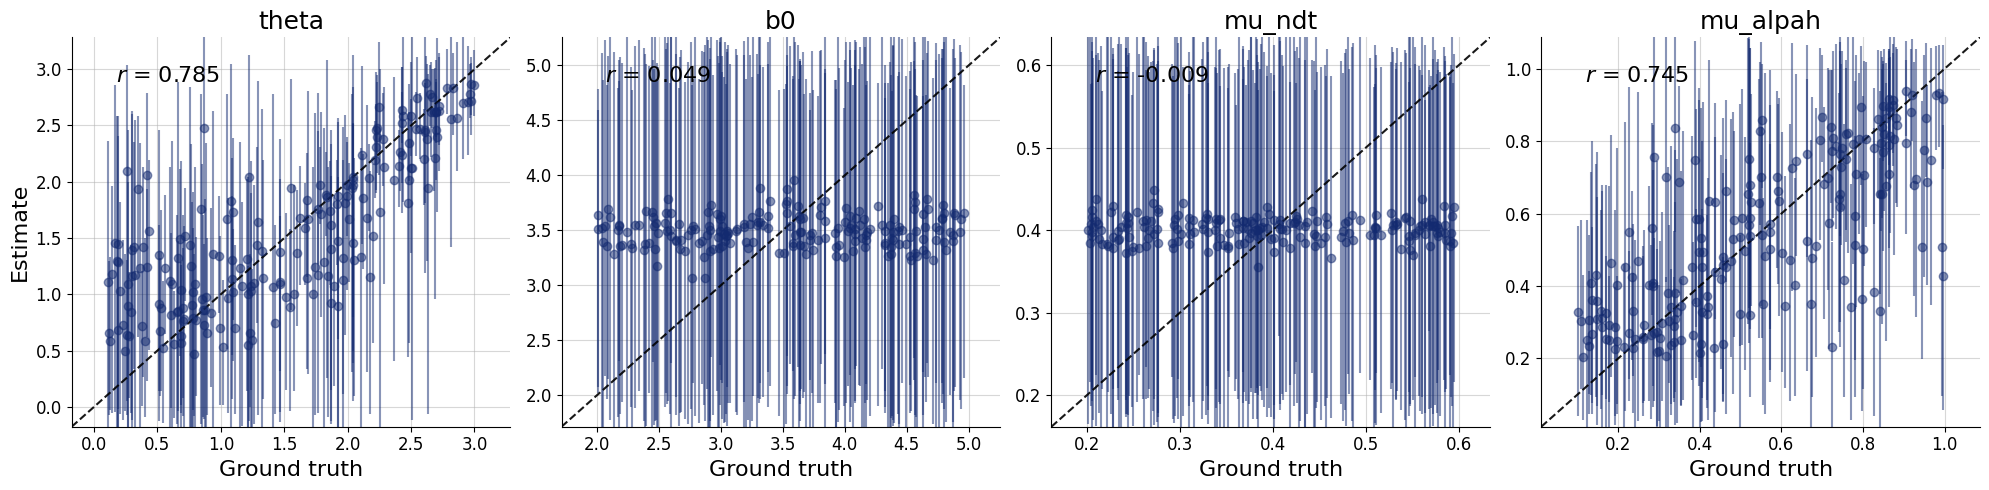

In [7]:
# Set the number of posterior draws you want to get
num_samples = 100

# Simulate validation data (unseen during training)
val_sims = model.sample(200)

post_draws1 = approximator.sample(conditions=val_sims, num_samples=num_samples)
par_keys = ["x"]
par_names = ['theta', 'b0', 'mu_ndt', 'mu_alpah']

f = bf.diagnostics.plots.recovery(
    estimates=post_draws1,
    targets=val_sims,
    variable_names=par_names
)

Sampling:   0%|          | 0/1 [00:00<?, ?batch/s]

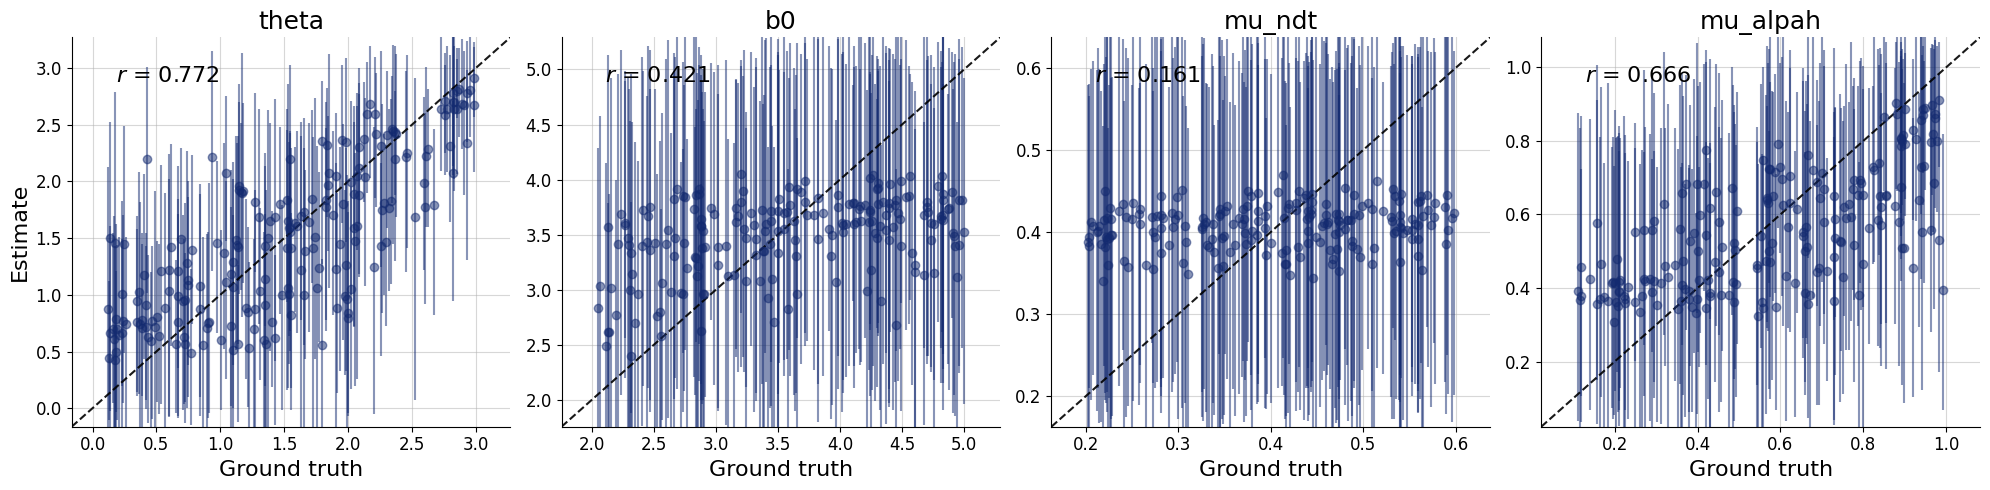

In [9]:
# Set the number of posterior draws you want to get
num_samples = 100

# Simulate validation data (unseen during training)
val_sims = model.sample(200)

post_draws1 = approximator.sample(conditions=val_sims, num_samples=num_samples)
par_keys = ["x"]
par_names = ['theta', 'b0', 'mu_ndt', 'mu_alpah']

f = bf.diagnostics.plots.recovery(
    estimates=post_draws1,
    targets=val_sims,
    variable_names=par_names
)

In [8]:
# Simulate validation data (unseen during training)
val_sims = model.sample(200)
val_sims

{'number_of_trials': 60,
 'tta_condition': np.float64(3.5),
 'theta': array([[1.64545375],
        [2.12953745],
        [2.19437683],
        [2.95473192],
        [1.88999727],
        [1.5264997 ],
        [0.24705264],
        [0.99597967],
        [2.98396412],
        [2.77054815],
        [0.4124635 ],
        [2.32556015],
        [2.26230844],
        [2.80029568],
        [0.745372  ],
        [0.60099949],
        [1.94856596],
        [0.33749676],
        [2.20339119],
        [2.41004287],
        [2.26564502],
        [0.87034894],
        [1.00359276],
        [0.29952238],
        [0.7551397 ],
        [2.47735748],
        [1.68001079],
        [1.00827121],
        [2.30862129],
        [0.93083317],
        [2.40252442],
        [1.8523256 ],
        [2.08630963],
        [0.51120748],
        [0.6082077 ],
        [1.8176753 ],
        [1.71406484],
        [0.54426823],
        [1.59399926],
        [1.94795734],
        [2.08161615],
        [0.50768924],
       

In [18]:
import matplotlib.pyplot as plt


In [22]:
val_sims.keys()

dict_keys(['number_of_trials', 'tta_condition', 'theta', 'b0', 'k', 'mu_ndt', 'sigma_ndt', 'mu_alpah', 'sigma_alpha', 'sigma_cpp', 'x', 'tta_per_trial'])

In [21]:
val_sims['x'][0].shape

(60, 1)

In [ ]:
val_sims["theta"]

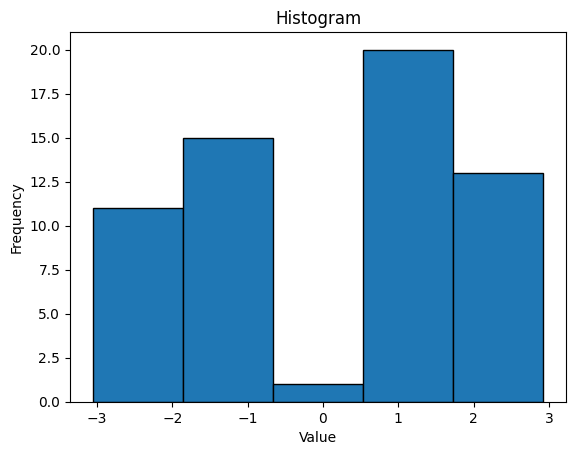

In [24]:
data = val_sims['x'][1]
plt.hist(data, bins=5, edgecolor='black')
plt.title("Histogram")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.show()

In [10]:
val_sims

{'number_of_trials': 60,
 'tta_condition': np.float64(4.0),
 'theta': array([[2.80393692],
        [0.33591415],
        [0.44372865],
        [2.43797007],
        [2.32652404],
        [1.78231683],
        [1.61898526],
        [2.81617222],
        [2.53033083],
        [1.53223847],
        [0.9432998 ],
        [2.82826414],
        [1.92618771],
        [1.26026827],
        [1.90504235],
        [0.45958835],
        [2.02086072],
        [2.12613393],
        [0.97565207],
        [0.15601371],
        [2.65101763],
        [2.22233822],
        [1.16493164],
        [1.61907378],
        [1.84285704],
        [2.68024525],
        [1.72793029],
        [1.90549427],
        [0.78368945],
        [1.20326458],
        [0.75505016],
        [0.96849376],
        [1.35998377],
        [0.13617067],
        [0.71024281],
        [0.52698348],
        [0.65200346],
        [0.420079  ],
        [2.04694435],
        [1.3752654 ],
        [2.93998705],
        [2.12449368],
       

### Test 1 Posterior estimated vs ground truth values
3 epochs 1000 iterations

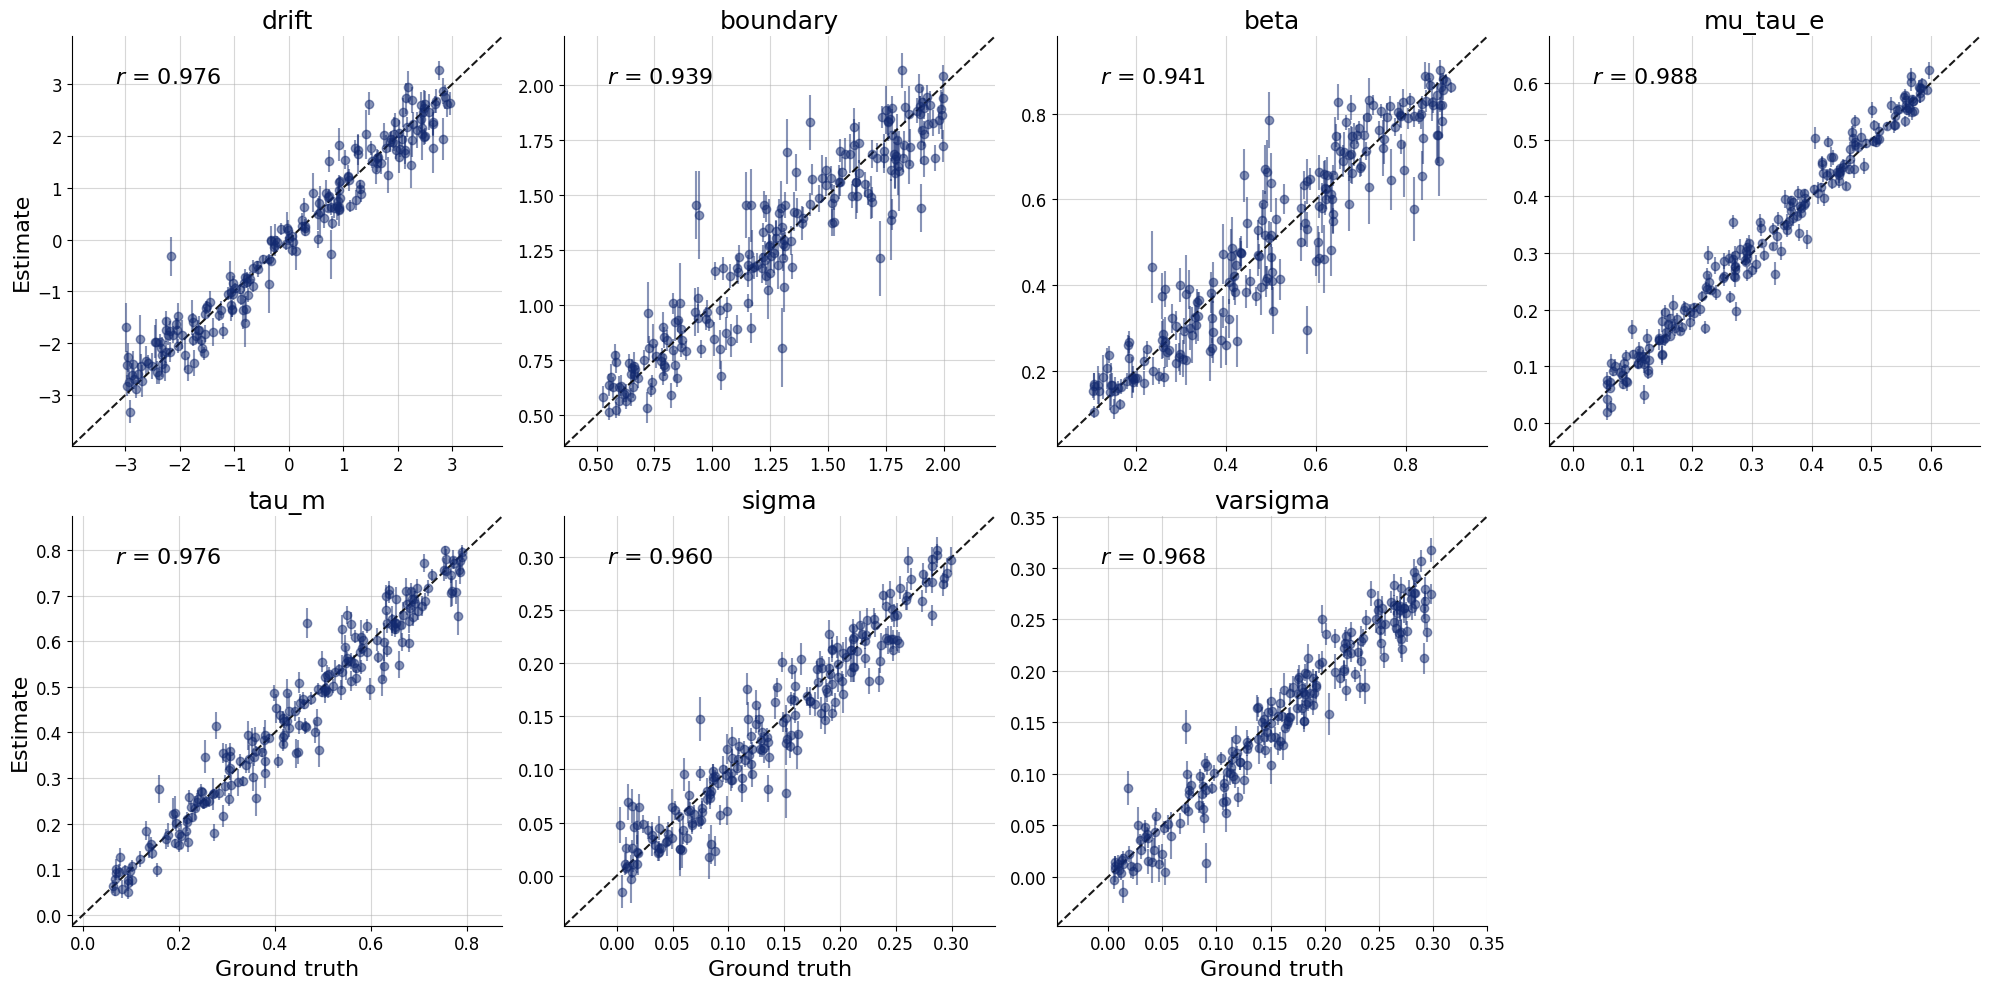

In [30]:
# Set the number of posterior draws you want to get
num_samples = 1000

# Simulate validation data (unseen during training)
val_sims = model.sample(200)

post_draws1 = approximator.sample(conditions=val_sims, num_samples=num_samples)
par_keys = ["x"]
par_names = ['drift',
        'boundary',
        'beta',
        'mu_tau_e',
        'tau_m',
        'sigma',
        'varsigma']
f = bf.diagnostics.plots.recovery(
    estimates=post_draws1,
    targets=val_sims,
    variable_names=par_names
)

In [6]:
model_name1

'model_1b'

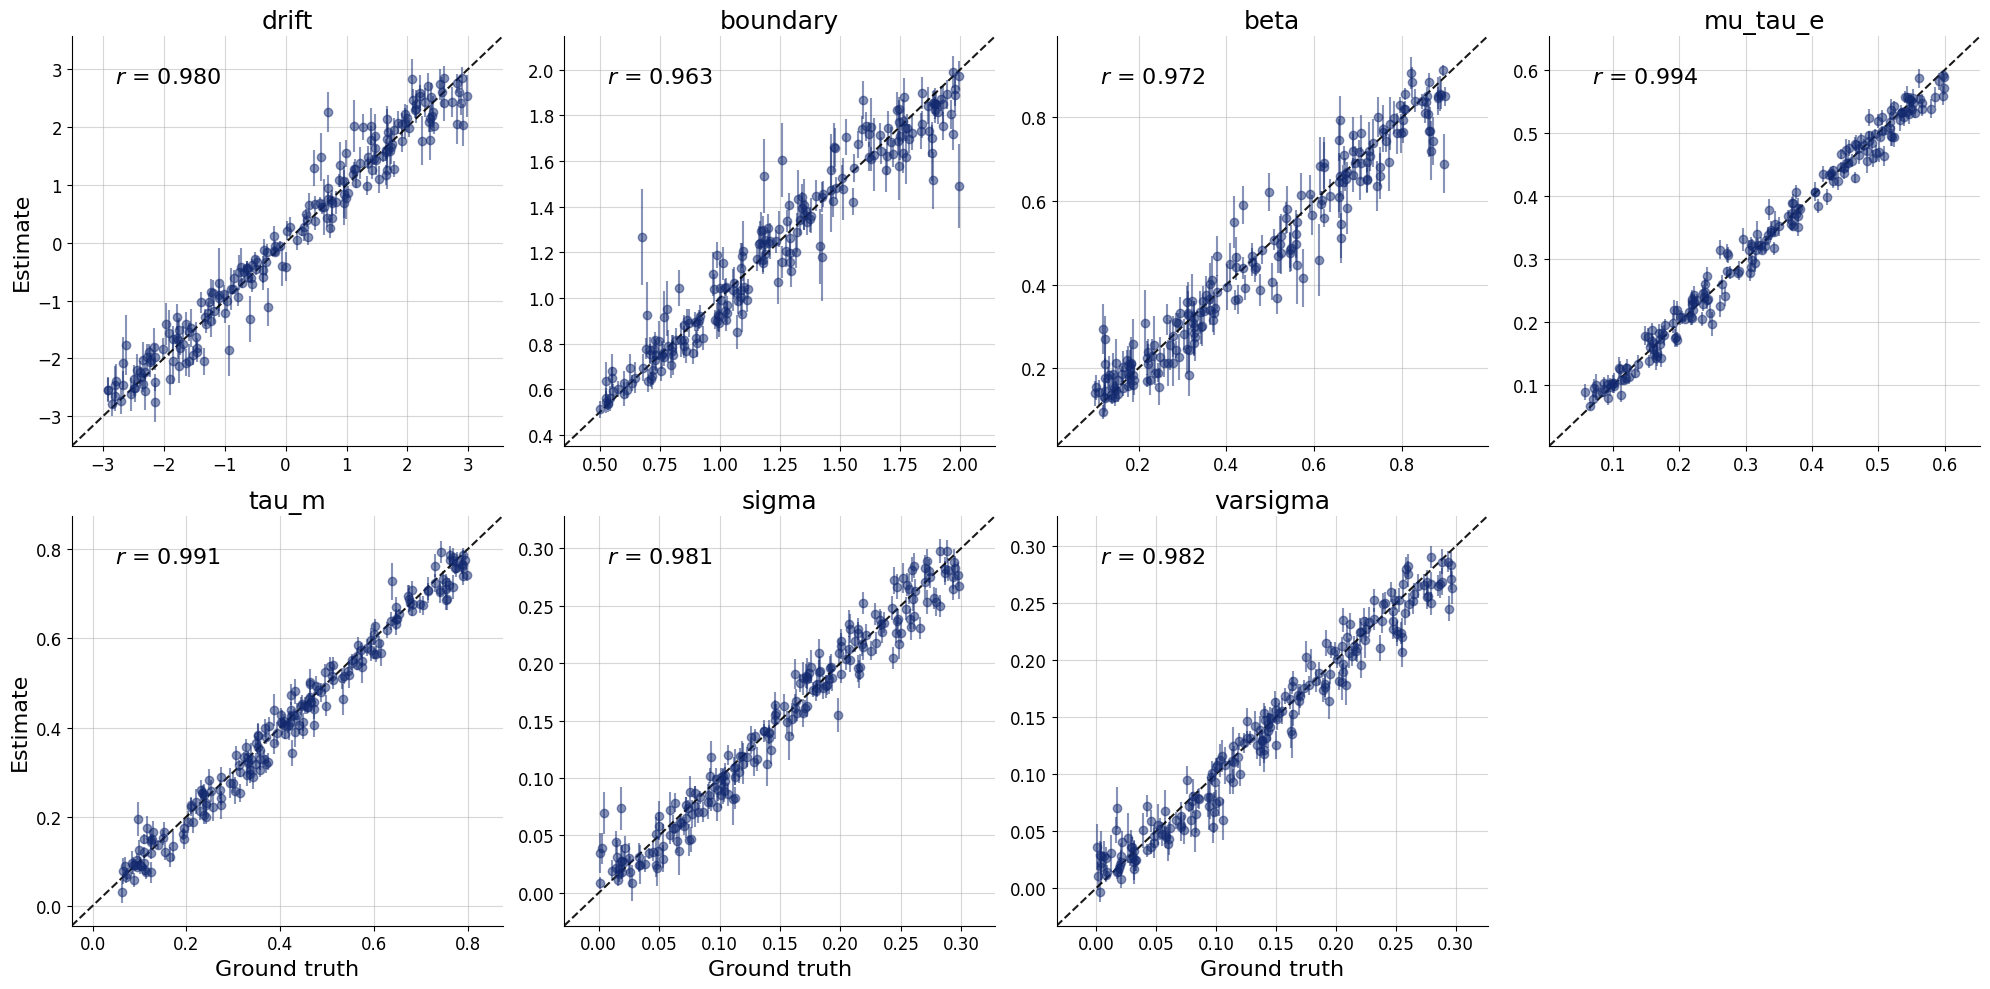

In [5]:
model_name1 = model_names[1]
save_path = os.path.join(save_dir, model_name1 + ".keras")
save_path
approximator = keras.saving.load_model(save_path)

model,adapt = all_models[model_name1]
model

# Set the number of posterior draws you want to get
num_samples = 1000

# Simulate validation data (unseen during training)
val_sims = model.sample(200)

post_draws1 = approximator.sample(conditions=val_sims, num_samples=num_samples)
par_keys = ["x"]
par_names = ['drift',
        'boundary',
        'beta',
        'mu_tau_e',
        'tau_m',
        'sigma',
        'varsigma']
f = bf.diagnostics.plots.recovery(
    estimates=post_draws1,
    targets=val_sims,
    variable_names=par_names
)

c:\Users\Mohammad\anaconda3\envs\bayseflow\lib\site-packages\keras\src\saving\saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 1 variables whereas the saved optimizer has 303 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


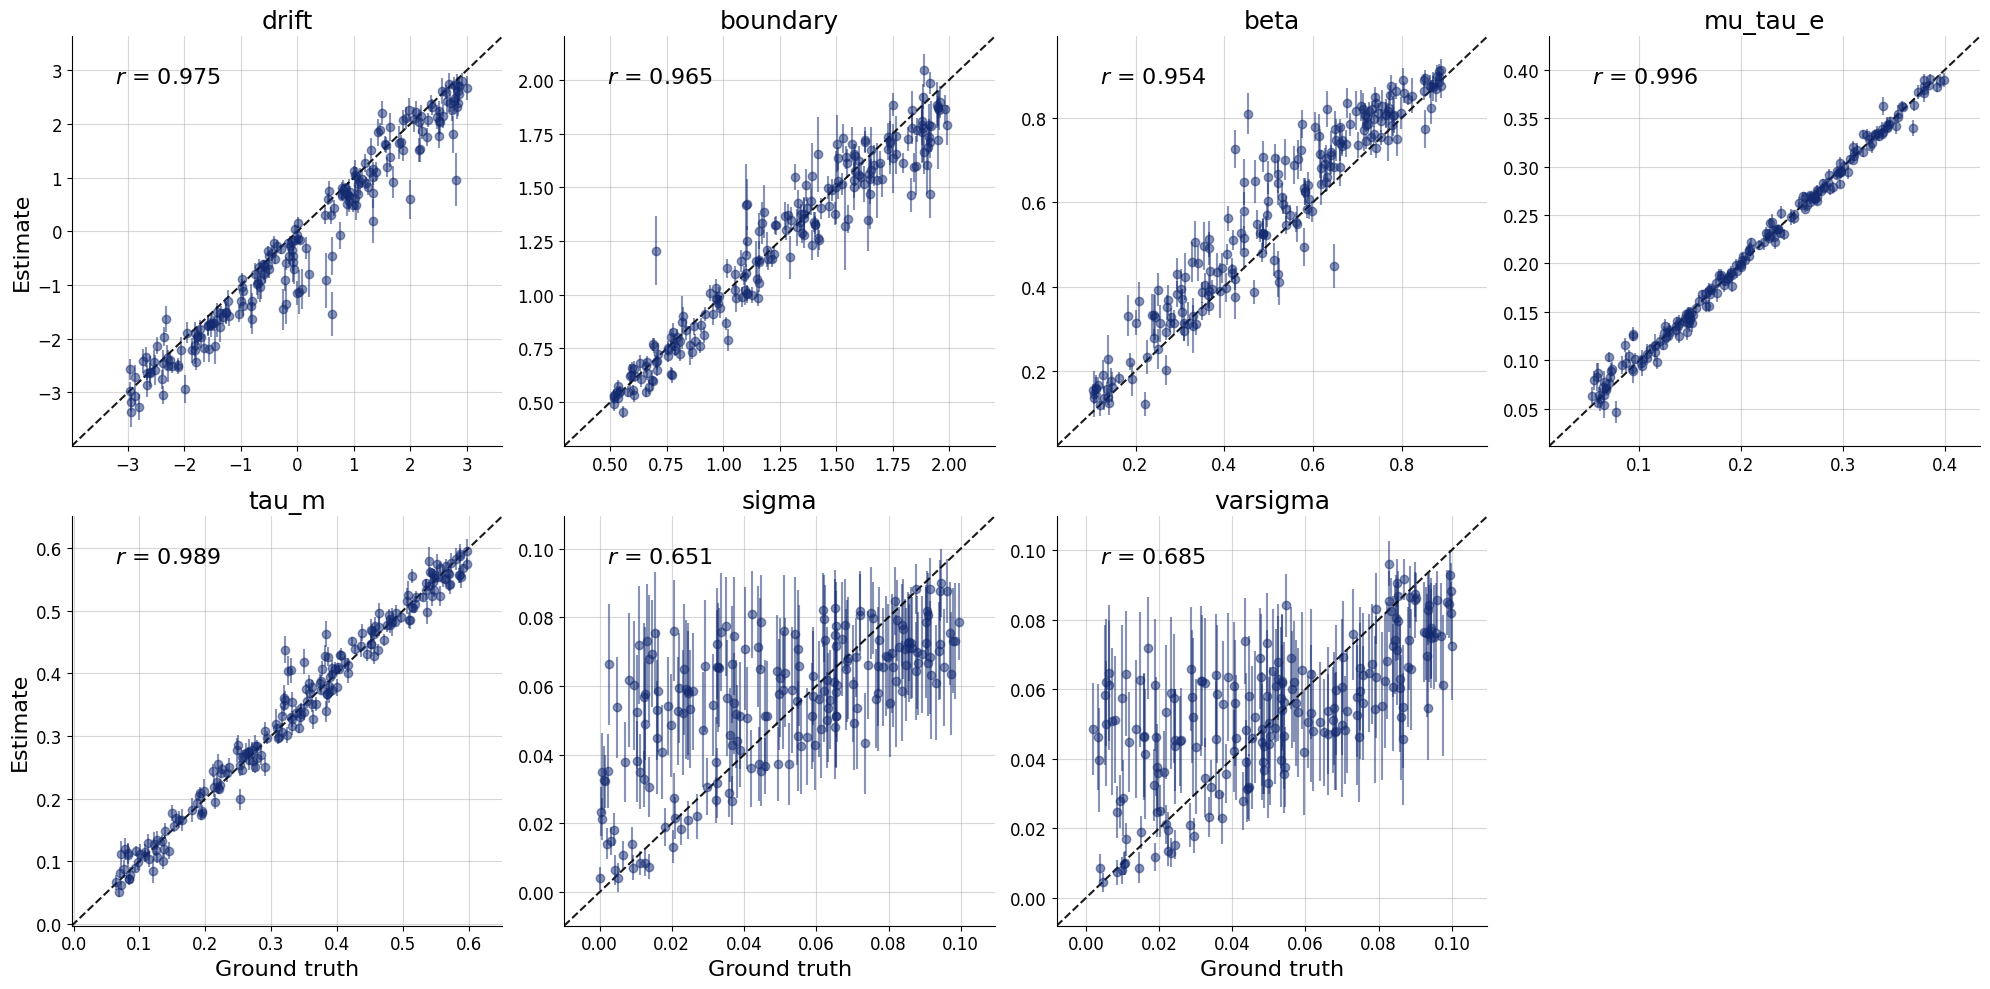

In [7]:
model_name1 = model_names[2]
save_path = os.path.join(save_dir, model_name1 + ".keras")
save_path
approximator = keras.saving.load_model(save_path)

model,adapt = all_models[model_name1]
model

# Set the number of posterior draws you want to get
num_samples = 1000

# Simulate validation data (unseen during training)
val_sims = model.sample(200)

post_draws1 = approximator.sample(conditions=val_sims, num_samples=num_samples)
par_keys = ["x"]
par_names = ['drift',
        'boundary',
        'beta',
        'mu_tau_e',
        'tau_m',
        'sigma',
        'varsigma']
f = bf.diagnostics.plots.recovery(
    estimates=post_draws1,
    targets=val_sims,
    variable_names=par_names
)

In [8]:
model_name1 = model_names[3]
save_path = os.path.join(save_dir, model_name1 + ".keras")
save_path
approximator = keras.saving.load_model(save_path)

model,adapt = all_models[model_name1]
model

# Set the number of posterior draws you want to get
num_samples = 1000

# Simulate validation data (unseen during training)
val_sims = model.sample(200)

post_draws1 = approximator.sample(conditions=val_sims, num_samples=num_samples)
par_keys = ["x"]
par_names = ['drift',
        'boundary',
        'beta',
        'mu_tau_e',
        'tau_m',
        'sigma',
        'varsigma']
f = bf.diagnostics.plots.recovery(
    estimates=post_draws1,
    targets=val_sims,
    variable_names=par_names
)

ValueError: Length of 'variable_names' should be the same as the number of variables.

### Test 2

In [ ]:
class prior(AB)